# Intent Classification on CLINC150 with Deep Neural Networks

**Deep Neural Networks - course project.**

**Goal:** build a proof-of-concept intent classifier with DNNs and evaluate whether it could
replace the LLM-based intent classifier used in my master's thesis project **SettleIn**
(an Agentic AI system for immigrant assistance in Serbia,
[github.com/IlorDash/settle-in](https://github.com/IlorDash/settle-in)).

Today SettleIn classifies user intent with a GPT-4o-mini API call. This project asks: can a small,
**fast, deterministic, cost-free** DNN do the job instead - including detecting **out-of-scope**
questions (queries outside supported topics)?

**Dataset - CLINC150:** 150 in-scope intent classes across 10 domains (banking, travel, work, ...),
plus a dedicated **out-of-scope (OOS)** class. We use `data_full.json`: 100 train / 20 val / 30 test
samples per in-scope intent, and 100 / 100 / 1000 OOS samples.

> **Application to SettleIn (no retraining):** once the classifier is trained, we select the CLINC150
> intents that match topics SettleIn supports (e.g. banking, travel, work, utilities) and treat every
> other intent - plus the native OOS class - as out-of-scope. The *same* model then acts as SettleIn's
> gatekeeper: route a supported topic, reject an unsupported one. That is exactly the decision
> SettleIn's orchestrator makes today with a GPT-4o-mini call. (A production system would later refine
> the relevant-intent set with real query logs - standard future work.)

## Plan
1. Load the data
2. Explore the data (EDA)
3. Turn text into numbers (TF-IDF vs. learned embeddings)
4. Baseline: TF-IDF + Dense MLP
5. Deep model 1: Embedding + pooling
6. Deep model 2: Embedding + Conv1D / BiLSTM
7. Tuning & comparison
8. Out-of-scope detection (confidence threshold vs. OOS-as-class)
9. Application to SettleIn: relevant-intent subset as a gatekeeper (no retraining)

## 1. Load the dataset

`data_full.json` has six top-level keys. Each maps to a list of `[text, intent]` pairs:

| Key | Contents | Size |
|-----|----------|------|
| `train` / `val` / `test` | in-scope, 150 intents | 15000 / 3000 / 4500 |
| `oos_train` / `oos_val` / `oos_test` | out-of-scope (label `"oos"`) | 100 / 100 / 1000 |

We keep the in-scope and out-of-scope splits **separate** because out-of-scope is open-ended
("anything the system doesn't support") and cannot be fully enumerated as training data. Keeping
them apart lets us test two OOS strategies later: detect OOS from the model's *confidence* (trained
on in-scope only), or add OOS as an explicit 151st class - and compare the two.

In [49]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

In [50]:
DATA_PATH = Path("data/data_full.json")

with open(DATA_PATH, encoding="utf-8") as f:
    clinc = json.load(f)

list(clinc.keys())

['oos_val', 'val', 'train', 'oos_test', 'test', 'oos_train']

In [51]:
def split_to_frame(pairs: list) -> pd.DataFrame:
    """Convert a list of [text, intent] pairs into a tidy DataFrame."""
    return pd.DataFrame(pairs, columns=["text", "intent"])


train_df = split_to_frame(clinc["train"])
val_df = split_to_frame(clinc["val"])
test_df = split_to_frame(clinc["test"])

oos_train_df = split_to_frame(clinc["oos_train"])
oos_val_df = split_to_frame(clinc["oos_val"])
oos_test_df = split_to_frame(clinc["oos_test"])

In [52]:
train_df.head()

,text,intent
0,what expression would i use to say i love you ...,translate
1,can you tell me how to say 'i do not speak muc...,translate
2,"what is the equivalent of, 'life is good' in f...",translate
3,"tell me how to say, 'it is a beautiful morning...",translate
4,"if i were mongolian, how would i say that i am...",translate


### Why three sets: train / validation / test

CLINC150 ships with **three** splits rather than the usual two. This structure exists to keep the
final score **honest**, and it shapes how we use each one.

| Split | Who uses it | Purpose | Touched |
|-------|-------------|---------|---------|
| **train** | the model | learns its weights (`fit`) | every epoch |
| **validation** | us | tuning decisions: when to stop, which model, which settings | constantly while developing |
| **test** | us, once | final unbiased score on unseen data | only at the very end |

**The trap with two sets:** every time we look at a score and *change something* (stop early, pick
64 units over 32, choose one model over another), that data has influenced our choices. If those
choices are guided by the test set, the test score becomes optimistic - it no longer predicts
performance on truly new data. The validation set is the one we are allowed to tune against; the
test set stays locked away until the final measurement.

So the three roles are: train to learn, validation to tune, and test to judge exactly once - an
approach called *hold-out evaluation*. Because the dataset provides the splits ready-made, every
researcher reports results on the same untouched test set, which keeps published numbers comparable.

## 2. Explore the data (EDA)

Before modelling we measure properties of the raw text, because each one feeds a concrete decision
later:

- **Class balance** -> is accuracy a fair metric, or do we lean on macro-F1?
- **Query length** -> what sequence length should we pad/truncate to?
- **Vocabulary size** -> how many tokens should the vectorizer keep?
- **Example queries** -> what does the text actually look like?
- **In-scope vs out-of-scope** -> can OOS be told apart by surface features, or only by meaning?

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

### Class balance

Each in-scope intent has the same number of training samples, so the dataset is balanced. That
means plain accuracy is not misleading - but with 150 classes we still report **macro-F1**, which
averages performance across classes equally and exposes any single intent the model handles badly.

In [54]:
intent_counts = train_df["intent"].value_counts()
intent_counts.describe()

count    150.0
mean     100.0
std        0.0
min      100.0
25%      100.0
50%      100.0
75%      100.0
max      100.0
Name: count, dtype: float64

### The 150 intents

The full list of intent labels. We use this later to pick the subset relevant to SettleIn
(banking, travel, work, utilities, ...) and treat the rest as out-of-scope.

In [55]:
sorted(train_df["intent"].unique())

['accept_reservations',
 'account_blocked',
 'alarm',
 'application_status',
 'apr',
 'are_you_a_bot',
 'balance',
 'bill_balance',
 'bill_due',
 'book_flight',
 'book_hotel',
 'calculator',
 'calendar',
 'calendar_update',
 'calories',
 'cancel',
 'cancel_reservation',
 'car_rental',
 'card_declined',
 'carry_on',
 'change_accent',
 'change_ai_name',
 'change_language',
 'change_speed',
 'change_user_name',
 'change_volume',
 'confirm_reservation',
 'cook_time',
 'credit_limit',
 'credit_limit_change',
 'credit_score',
 'current_location',
 'damaged_card',
 'date',
 'definition',
 'direct_deposit',
 'directions',
 'distance',
 'do_you_have_pets',
 'exchange_rate',
 'expiration_date',
 'find_phone',
 'flight_status',
 'flip_coin',
 'food_last',
 'freeze_account',
 'fun_fact',
 'gas',
 'gas_type',
 'goodbye',
 'greeting',
 'how_busy',
 'how_old_are_you',
 'improve_credit_score',
 'income',
 'ingredient_substitution',
 'ingredients_list',
 'insurance',
 'insurance_change',
 'interest_rat

### Query length

How long are the queries, in words? This sets the sequence length we pad/truncate to for the
embedding models: too short loses information, too long wastes computation on padding.

In [56]:
train_df["n_words"] = train_df["text"].str.split().str.len()
train_df["n_words"].describe()

count    15000.000000
mean         8.339200
std          3.191868
min          1.000000
25%          6.000000
50%          8.000000
75%         10.000000
max         28.000000
Name: n_words, dtype: float64

In [57]:
# Percentiles guide the padding length: cover almost every query without an extreme max.
train_df["n_words"].quantile([0.5, 0.95, 0.99, 1.0])

0.50     8.0
0.95    14.0
0.99    17.0
1.00    28.0
Name: n_words, dtype: float64

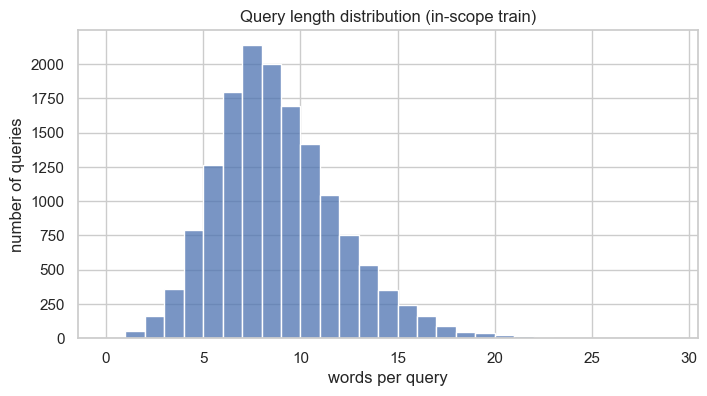

In [58]:
plt.figure(figsize=(8, 4))
sns.histplot(train_df["n_words"], bins=range(0, train_df["n_words"].max() + 2))
plt.xlabel("words per query")
plt.ylabel("number of queries")
plt.title("Query length distribution (in-scope train)")
plt.show()

### Vocabulary size

The number of distinct words across the training set. This sets a ceiling for the vectorizer's
vocabulary - the number of TF-IDF features, or the Embedding layer's input dimension. The TF-IDF
vectorizer in Section 3.2 keeps fewer than this (about 2770), because `min_df=2` removes the many
words that appear in only a single query.

In [59]:
vocabulary = set()
for text in train_df["text"]:
    vocabulary.update(text.lower().split())

len(vocabulary)

5863

### Example queries per intent

What does the raw text look like? Three examples from the first five intents (alphabetically).

In [60]:
for intent in sorted(train_df["intent"].unique())[:5]:
    print(f"\n=== {intent} ===")
    for text in train_df.loc[train_df["intent"] == intent, "text"].head(3):
        print(" -", text)


=== accept_reservations ===
 - can i make a reservation for redrobin
 - is it possible to make a reservation at redrobin
 - does redrobin take reservations

=== account_blocked ===
 - why is there a hold on my american saving bank account
 - i am nost sure why my account is blocked
 - why is there a hold on my capital one checking account

=== alarm ===
 - wake me up at noon tomorrow
 - set my alarm for getting up
 - make sure my alarm is set for three thirty in the morning

=== application_status ===
 - when will my application for my credit card be processed
 - has the discover card approved my app
 - do you know if my amex card app went through

=== apr ===
 - is the apr on my credit card good
 - how good is the apr on my credit card
 - do i have a good apr on my credit card


### In-scope vs out-of-scope

First some real out-of-scope queries, then a comparison of length distributions. If in-scope and
OOS look similar on the surface, OOS detection must rely on **meaning**, not superficial cues - the
motivation for the confidence-threshold approach.

In [61]:
oos_test_df["text"].head(10).tolist()

['how much has the dow changed today',
 'how many prime numbers are there between 0 and 100',
 'can you tell me how to solve simple algebraic equations with one variable',
 'can you dim the brightness of my screen',
 'what is the account number to the internet service i have',
 'can you see a hdmi cord',
 'what veggies can i pair with mushrooms',
 'can you put the car in fuel efficient mode',
 'at what age can someone get a card',
 "please find today's most read stories from the new york times todayi"]

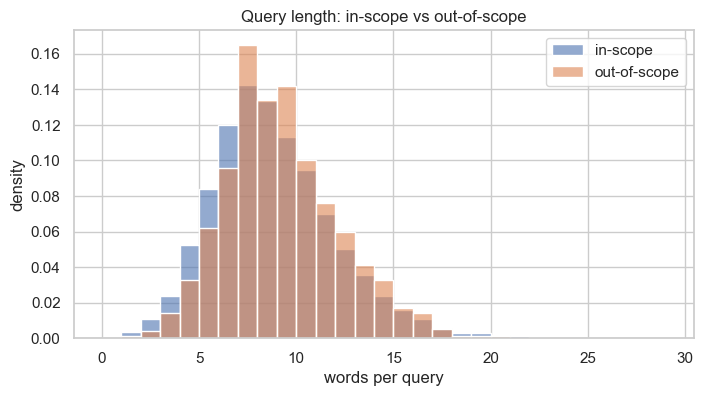

In [62]:
oos_test_df["n_words"] = oos_test_df["text"].str.split().str.len()

plt.figure(figsize=(8, 4))
sns.histplot(train_df["n_words"], bins=range(0, 30), stat="density",
             label="in-scope", color="C0", alpha=0.6)
sns.histplot(oos_test_df["n_words"], bins=range(0, 30), stat="density",
             label="out-of-scope", color="C1", alpha=0.6)
plt.xlabel("words per query")
plt.ylabel("density")
plt.title("Query length: in-scope vs out-of-scope")
plt.legend()
plt.show()

## 3. Turn text into numbers

A network can't read strings. We need two separate conversions:

1. **Labels**: intent *names* -> integer class IDs (this section, 3.1).
2. **Features**: query *text* -> numeric vectors (3.2, TF-IDF for the baseline).

We start with the labels because every model - baseline and deep - needs them in this form. Using
`sparse_categorical_crossentropy` later means the labels stay as plain integers, with no one-hot
encoding step required.

### 3.1 Encode the labels

`LabelEncoder` maps each of the 150 intent names to an integer 0-149. We **fit on the training
intents only**, then reuse that mapping for val and test so a given intent always gets the same ID.
We keep the encoder to translate predictions back to names later via `inverse_transform`.

In [63]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
label_encoder.fit(train_df["intent"])

y_train = label_encoder.transform(train_df["intent"])
y_val = label_encoder.transform(val_df["intent"])
y_test = label_encoder.transform(test_df["intent"])

num_classes = len(label_encoder.classes_)
num_classes

150

In [64]:
# class i corresponds to label_encoder.classes_[i]
list(enumerate(label_encoder.classes_[:5]))

[(0, 'accept_reservations'),
 (1, 'account_blocked'),
 (2, 'alarm'),
 (3, 'application_status'),
 (4, 'apr')]

### 3.2 Vectorize the text (TF-IDF)

`TfidfVectorizer` turns each query into a numeric vector - one weight per word in the *vocabulary*.
The vocabulary is the set of distinct words the vectorizer knows about, collected from the training
text. We **fit on the training text only** (the same anti-leakage rule as scaling in the course
notebooks), then transform every split with that fixed vocabulary.

`min_df=2` drops words appearing in only a single query: they can't help the model generalize and
would only inflate the feature space. The sections below unpack what TF-IDF computes, what `fit` and
`transform` do, and what the resulting matrix actually looks like.

In [65]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(min_df=2)
X_train = vectorizer.fit_transform(train_df["text"])
X_val = vectorizer.transform(val_df["text"])
X_test = vectorizer.transform(test_df["text"])

X_train.shape, X_val.shape, X_test.shape

((15000, 2770), (3000, 2770), (4500, 2770))

**Why 2770 features and not the 5863 from the EDA?** The earlier count split on spaces and kept
*every* distinct token, including the many words that appear in just one query. `TfidfVectorizer` is
stricter: `min_df=2` drops every word occurring in fewer than two queries (a large share of those
5863), and its tokenizer also discards one-letter tokens like "i" and "a". What remains - 2770
words - are the ones common enough to be useful, shared features.

### The math behind TF-IDF

TF-IDF converts a query into numbers with **no training** - it is pure counting plus one formula.
Each word's weight is built from two factors:

**TF (term frequency)** - how often a word appears *in this one query*.
- More occurrences in the query -> higher weight.
- It is a property of a (word, query) pair, so it is recomputed for every query during `transform`.

**IDF (inverse document frequency)** - how rare a word is *across all training queries*.
- A single fixed number per word, learned during `fit` and stored in `vectorizer.idf_`.
- scikit-learn's formula, where `N` = number of training queries and `df` (the *document
  frequency*) = how many of them contain the word:

```
idf(word) = ln( (1 + N) / (1 + df(word)) ) + 1
```

- A word in *many* queries ("to", "what") -> small idf. A *rare* word ("italian") -> large idf.

**The stored weight** is their product, after which each row is scaled to unit length:

```
weight(word, query) = tf(word, query) * idf(word)
```

Putting it together: TF measures local frequency (within one query) and IDF measures global rarity
(across the whole corpus), so a high weight marks a word that is frequent here but rare overall -
exactly the kind of word that signals intent. Common filler words such as "the" or "to" sink toward
zero automatically, with no need for a stop-word list.

In [66]:
# Each word's learned IDF, lowest (most common) first.
# idf_ is aligned with get_feature_names_out() (same column order), not with vocabulary_.items().
pd.Series(vectorizer.idf_, index=vectorizer.get_feature_names_out()).sort_values().head(10)

my      2.047226
to      2.177722
the     2.409289
what    2.595602
you     2.651716
me      2.825590
for     2.832232
is      2.909259
how     2.971910
can     3.101072
dtype: float64

In [67]:
# The non-zero TF-IDF weights of the first training query, highest first.
first_query = pd.Series(
    X_train[0].toarray().ravel(),
    index=vectorizer.get_feature_names_out(),
)
first_query[first_query > 0].sort_values(ascending=False)

love       0.434452
italian    0.430337
were       0.367519
say        0.331239
use        0.301759
an         0.280323
would      0.271659
if         0.268281
you        0.158168
what       0.154821
to         0.129896
dtype: float64

### fit, transform, fit_transform - and why only train is fitted

The vectorizer is a **stateful object** - a translator that first needs an internal dictionary
(which words exist, their column, their idf) before it can convert anything.

| Method | What it does | Changes the object? | Returns |
|--------|--------------|---------------------|---------|
| `fit(texts)` | reads texts and **builds** the vocabulary + idf inside the object | yes | the object |
| `transform(texts)` | converts texts into vectors **using the stored dictionary** | no (read-only) | the matrix |
| `fit_transform(texts)` | `fit` then `transform`, in one call | yes | the matrix |

After `fit`, the learned state lives in attributes ending with `_`: `vectorizer.vocabulary_`
(word -> column index) and `vectorizer.idf_` (one number per word). The trailing underscore is
scikit-learn's convention for "learned from data".

We call `fit_transform` on train but only `transform` on val and test, for two reasons:

1. **No data leakage.** *Data leakage* is when information from the validation or test set influences
   training or preprocessing, making the final score look better than it truly is. Because `fit`
   measures statistics from whatever it sees, it must touch the training data only.
2. **Matching columns.** The model expects a fixed 2770-column input. `transform` forces every split
   into that same vocabulary; a val/test word unseen in training is simply dropped (no column),
   exactly as a brand-new user query would be in production.

This mirrors the course notebooks' pattern: `MinMaxScaler.fit(train)` then `transform(test)` - learn
the rule on the training data, then apply it everywhere.

### What we get back: a sparse matrix

`transform` returns a matrix with **one row per query** and **one column per vocabulary word** (2770
columns). Cell `[query, word]` holds that word's TF-IDF weight in that query, or `0` if the word is
absent. Each row is therefore a *bag-of-words* representation: it records which words appear and how
strongly, but discards their order.

Because a query uses only ~8 words out of 2770, **almost every cell is 0**. A matrix that is mostly
zeros is called a *sparse matrix*. Instead of storing 15000 x 2770 = ~41 million numbers, SciPy keeps
*only the non-zero entries and their positions* - that is why `X_train` prints as a one-line summary,
not a grid, and why it stays small in memory.

The toy example below makes it concrete: 3 sentences become a small grid where each row has a few
weights and the rest are zeros. The real `X_train` is the same picture at 15000 x 2770.

In [68]:
# A toy TF-IDF on 3 short sentences, shown as a full (dense) grid so the zeros are visible.
# The real X_train is this same idea, just 15000 x 2770.
demo_texts = [
    "transfer money to my account",
    "what is my account balance",
    "book a flight to rome",
]
demo_vectorizer = TfidfVectorizer()
demo_matrix = demo_vectorizer.fit_transform(demo_texts)

pd.DataFrame(
    demo_matrix.toarray().round(2),
    columns=demo_vectorizer.get_feature_names_out(),
    index=demo_texts,
)

,account,balance,book,flight,is,money,my,rome,to,transfer,what
transfer money to my account,0.39,0.00,0.00,0.00,0.00,0.52,0.39,0.00,0.39,0.52,0.00
what is my account balance,0.37,0.49,0.00,0.00,0.49,0.00,0.37,0.00,0.00,0.00,0.49
book a flight to rome,0.00,0.00,0.53,0.53,0.00,0.00,0.00,0.53,0.40,0.00,0.00


In [69]:
# How sparse is the real matrix? Non-zero cells vs total cells.
non_zero = X_train.nnz
total = X_train.shape[0] * X_train.shape[1]
print(f"non-zero cells: {non_zero:,} out of {total:,}")
print(f"fraction non-zero: {non_zero / total:.4%}")

non-zero cells: 111,325 out of 41,550,000
fraction non-zero: 0.2679%


## Why these four models

We compare four models, ordered from simplest to most order-aware, so each step adds exactly one new
capability and the comparison shows whether that capability actually helps on CLINC150:

| Model | New capability over the previous | Uses word order? |
|-------|----------------------------------|------------------|
| TF-IDF + MLP | hand-crafted word-frequency features (baseline) | no |
| Embedding + pooling | *learns* word meanings instead of hand-crafting them | no |
| Embedding + Conv1D | detects short local word patterns (n-grams) | local |
| Embedding + BiLSTM | reads the whole sequence in both directions with memory | full |

This ladder is the experiment: if a more capable model does not beat a simpler one, we learn that
the extra capability is not what limits accuracy on this data.

**Why not other models.**
- *Transformers / BERT* would likely score higher, but they are large, need a GPU, and rely on heavy
  pretraining - which contradicts the goal of a small, fast, cost-free classifier. We note them as a
  future upgrade instead.
- *Classic ML* (SVM, logistic regression, naive Bayes) can match TF-IDF on this kind of data, but the
  course is about deep neural networks, so we stay within the neural-network family.
- *Pretrained sentence encoders* (e.g. Universal Sentence Encoder) bring outside language knowledge
  and would probably win, but the aim is to learn DNN architectures ourselves rather than plug in a
  finished encoder - again, noted as future work.

## 4. Baseline model: TF-IDF + Dense MLP

A *baseline* is a deliberately simple model whose job is to set a score the deeper models must beat:
if a more complex architecture cannot outperform a plain one, the complexity is not worth it.

This baseline is a small feed-forward network (a *multi-layer perceptron*, or MLP) that takes the
2770 TF-IDF features of a query and predicts one of the 150 intents. It is the same kind of network
as the classification notebook from the course, with two changes for multi-class output:

- the output layer has **150 units with a softmax** activation (one probability per intent) instead
  of a single sigmoid;
- the loss is **`sparse_categorical_crossentropy`**, which reads the integer labels directly.

*Softmax* is the activation on that output layer. It takes the 150 raw scores the network produces
(any numbers, positive or negative) and turns them into 150 probabilities between 0 and 1 that add
up to 1 - a probability distribution over the intents. It works by exponentiating each score and
dividing by the sum of all of them, so a larger score becomes a larger probability while the total
stays at 1. The predicted intent is the one with the highest probability, and that probability also
measures how confident the model is - exactly the signal we will later use to flag out-of-scope
queries. (Softmax is the multi-class version of the sigmoid used for binary classification.)

#### Softmax in one picture

The left chart shows five example raw scores (logits) - they can be any size, even negative. The
right chart shows the same five values after softmax: each is now between 0 and 1, and together they
add up to 1, with the largest score keeping the largest share. Softmax does this by raising `e` to
each score (which is always positive) and then dividing by the total. Try editing `example_logits`
to see how the probabilities shift.

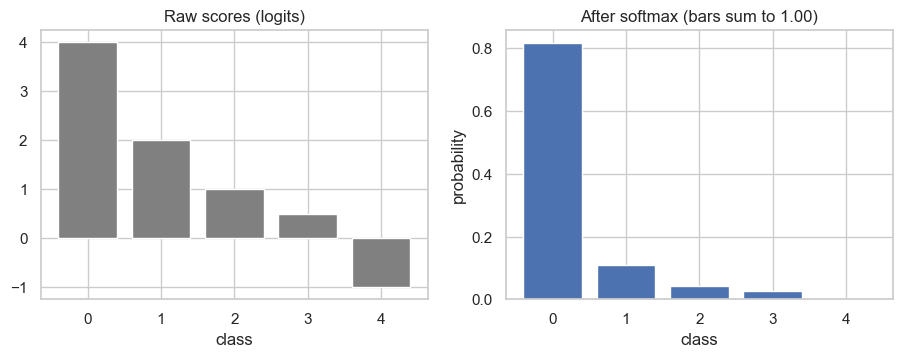

In [70]:
# Softmax turns raw scores (logits) into probabilities that sum to 1.
example_logits = np.array([4.0, 2.0, 1.0, 0.5, -1.0])
probabilities = np.exp(example_logits) / np.exp(example_logits).sum()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].bar(range(len(example_logits)), example_logits, color="gray")
axes[0].set_title("Raw scores (logits)")
axes[0].set_xlabel("class")

axes[1].bar(range(len(probabilities)), probabilities, color="C0")
axes[1].set_title(f"After softmax (bars sum to {probabilities.sum():.2f})")
axes[1].set_xlabel("class")
axes[1].set_ylabel("probability")
plt.show()

In [71]:
# Keras Dense layers need a dense array, so expand the sparse matrices to float32.
# 15000 x 2770 floats is about 166 MB - safe in memory.
X_train_dense = X_train.toarray().astype("float32")
X_val_dense = X_val.toarray().astype("float32")
X_test_dense = X_test.toarray().astype("float32")

X_train_dense.shape

(15000, 2770)

### Build the network

We use **two hidden layers** (256 then 128 units), which makes this a genuinely deep network. Each
`Dense` layer with a *ReLU* activation learns combinations of its inputs - *ReLU* (rectified linear
unit) replaces negative values with zero, which lets the network learn non-linear patterns rather
than only straight-line ones. A `Dropout(0.5)` after each hidden layer randomly zeroes half the
activations during training to reduce overfitting, and the final `Dense(150)` with softmax produces
the per-intent probabilities.

We compile with the *Adam optimizer* - the algorithm that nudges the weights to lower the loss each
step, a robust, widely used default. A fixed random seed keeps the run reproducible.

In [72]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

tf.keras.utils.set_random_seed(42)

n_features = X_train_dense.shape[1]

baseline_model = Sequential([
    Input(shape=(n_features,)),
    Dense(256, activation="relu"),
    Dropout(0.5),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(num_classes, activation="softmax"),
])

baseline_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

baseline_model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_19 (Dense)                │ (None, 256)            │       709,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 150)            │        19,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 761,622 (2.91 MB)

 Trainable params: 761,622 (2.91 MB)

 Non-trainable params: 0 (0.00 B)

### Train with early stopping

We train on the TF-IDF features and watch the **validation loss**. *Early stopping* halts training
once `val_loss` stops improving for `patience` epochs, and `restore_best_weights=True` rolls the
model back to its best epoch - so we neither under- nor over-train. The test set is not touched
here; it stays reserved for the final comparison.

In [73]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)

history = baseline_model.fit(
    X_train_dense, y_train,
    validation_data=(X_val_dense, y_val),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
)

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1159 - loss: 4.6634 - val_accuracy: 0.6740 - val_loss: 3.5595
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4823 - loss: 2.5265 - val_accuracy: 0.8357 - val_loss: 1.1965
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6938 - loss: 1.3030 - val_accuracy: 0.8640 - val_loss: 0.6916
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7825 - loss: 0.8827 - val_accuracy: 0.8797 - val_loss: 0.5390
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8349 - loss: 0.6634 - val_accuracy: 0.8880 - val_loss: 0.4701
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8616 - loss: 0.5361 - val_accuracy: 0.8910 - val_loss: 0.4423
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8859 - loss: 0.4541 - val_accuracy: 0.8963 - val_loss: 0.4235
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8993 - loss: 0.3862 - val_accuracy: 0.

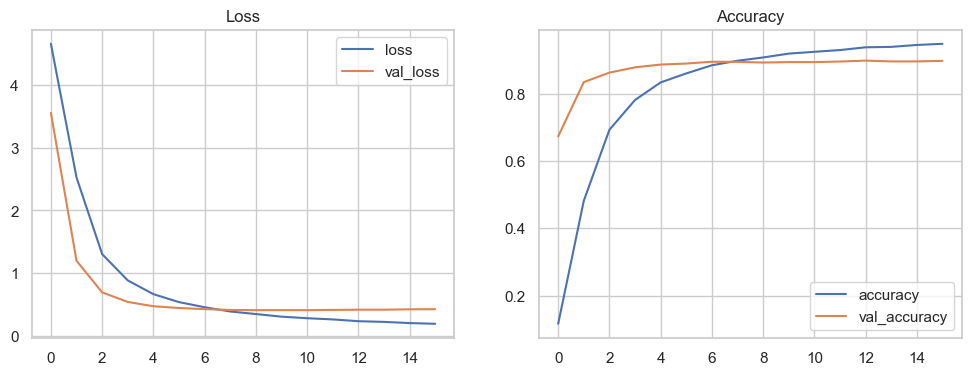

In [74]:
history_df = pd.DataFrame(history.history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
history_df[["loss", "val_loss"]].plot(ax=axes[0], title="Loss")
history_df[["accuracy", "val_accuracy"]].plot(ax=axes[1], title="Accuracy")
plt.show()

### Reading the training curves

Both plots share the same x-axis: the **epoch**, one full pass of training over all 15000 training
queries.

- **Loss** (left) is the quantity the model minimizes; lower is better. The `loss` line is measured
  on the training set, `val_loss` on the validation set.
- **Accuracy** (right) is the fraction of correct predictions; higher is better, again split into
  training and validation.

How to read them:
- Both losses falling and then flattening means the model learned and converged.
- If training keeps improving while validation stalls or worsens, that gap is **overfitting** - the
  model is memorizing the training set instead of generalizing. `val_loss` turning upward is the
  classic sign, and it is exactly where early stopping halts and restores the best epoch.
- The epoch with the lowest `val_loss` is the model we keep.

### Evaluate on the validation set

We report two numbers on the validation set. *Accuracy* is the fraction of queries given the correct
intent. *Macro-F1* is the F1 score (the balance of precision and recall) averaged equally over all
150 intents, so a handful of badly handled intents cannot hide behind the rest. These are the
baseline numbers the deeper models will try to beat.

In [75]:
from sklearn.metrics import accuracy_score, f1_score

val_pred = baseline_model.predict(X_val_dense).argmax(axis=1)

print(f"validation accuracy: {accuracy_score(y_val, val_pred):.4f}")
print(f"validation macro-F1: {f1_score(y_val, val_pred, average='macro'):.4f}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
validation accuracy: 0.8953
validation macro-F1: 0.8943


## 5. Deep model 1: Embedding + pooling

The baseline treated each word as an isolated feature: "transfer" and "transaction" were two
unrelated columns, and word order was thrown away. This model fixes the first problem with **word
embeddings**.

An *embedding* is a short list of numbers (a vector) attached to each word and *learned during
training*. Words used in similar ways end up with similar vectors, so the model can generalize -
seeing "transfer" at training time also teaches it something about "transaction". Instead of one
fixed bag-of-words vector per query, each query becomes a *sequence* of these word vectors.

The plan for this section:
1. turn each query into a padded sequence of integer word IDs;
2. let an `Embedding` layer map each ID to a learned vector;
3. average those vectors into one summary vector (pooling) and classify it with a softmax.

### 5.1 Turn text into padded integer sequences

The embedding layer needs each word as an integer ID, not a TF-IDF weight. Keras' `TextVectorization`
layer builds a vocabulary from the training text and maps each query to a list of integer IDs.

Two settings matter:
- `max_tokens` caps the vocabulary at the most frequent words (we use 5000).
- `output_sequence_length` fixes every sequence to the same length by *padding* short queries with
  zeros and truncating long ones. From the EDA, 99% of queries are <= 17 words, so a length of 20
  covers almost all of them with little waste.

We `adapt` the layer on the training text only (the same fit-on-train rule), then apply it to every
split.

In [76]:
from tensorflow.keras.layers import TextVectorization

MAX_LEN = 20
VOCAB_SIZE = 5000

vectorize_layer = TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode="int",
    output_sequence_length=MAX_LEN,
)
vectorize_layer.adapt(train_df["text"].to_numpy())

X_train_seq = vectorize_layer(train_df["text"].to_numpy()).numpy()
X_val_seq = vectorize_layer(val_df["text"].to_numpy()).numpy()
X_test_seq = vectorize_layer(test_df["text"].to_numpy()).numpy()

X_train_seq.shape

(15000, 20)

In [77]:
# One query as raw text vs. its padded integer sequence (0 = padding).
print(train_df["text"].iloc[0])
print(X_train_seq[0])

what expression would i use to say i love you if i were an italian
[   9 4410   45    3   75    4  116    3  522    6   43    3  193   49
  501    0    0    0    0    0]


### 5.2 Build the embedding model

Three new layers replace the TF-IDF input:

- **`Embedding`** holds one learned vector per vocabulary word (here 64 numbers each). It turns a
  length-20 sequence of IDs into a 20 x 64 grid of word vectors. `mask_zero=True` tells the later
  layers to ignore the padding positions.
- **`GlobalAveragePooling1D`** averages the 20 word vectors into a single 64-number vector that
  summarizes the whole query.
- A final **`Dense(150)` softmax** classifies that summary, exactly as in the baseline.

Averaging still ignores word order - we address that in Section 6 - but the word vectors themselves
are learned and shared, which is the gain over bag-of-words.

In [78]:
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D

EMBED_DIM = 64
vocab_size = vectorize_layer.vocabulary_size()

tf.keras.utils.set_random_seed(42)

embedding_model = Sequential([
    Input(shape=(MAX_LEN,), dtype="int32"),
    Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, mask_zero=True),
    GlobalAveragePooling1D(),
    Dense(64, activation="relu"),
    Dropout(0.5),
    Dense(num_classes, activation="softmax"),
])

embedding_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

embedding_model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 20, 64)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 150)            │         9,750 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,910 (1.27 MB)

 Trainable params: 333,910 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

### 5.3 Train and evaluate

We reuse the baseline's recipe: train on the integer sequences with early stopping on the validation
loss, then read the loss and accuracy curves the same way. The validation accuracy and macro-F1 at
the end are what we compare against the baseline (0.915 accuracy).

In [79]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)

embedding_history = embedding_model.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
)

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0757 - loss: 4.8480 - val_accuracy: 0.2060 - val_loss: 4.3619
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2349 - loss: 3.5938 - val_accuracy: 0.5827 - val_loss: 2.6680
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4505 - loss: 2.3411 - val_accuracy: 0.7287 - val_loss: 1.6762
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6012 - loss: 1.6581 - val_accuracy: 0.7947 - val_loss: 1.2077
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6856 - loss: 1.2637 - val_accuracy: 0.8287 - val_loss: 0.9637
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7522 - loss: 1.0187 - val_accuracy: 0.8460 - val_loss: 0.8241
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7870 - loss: 0.8486 - val_accuracy: 0.8597 - val_loss: 0.7349
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8262 - loss: 0.7123 - val_accuracy: 0.

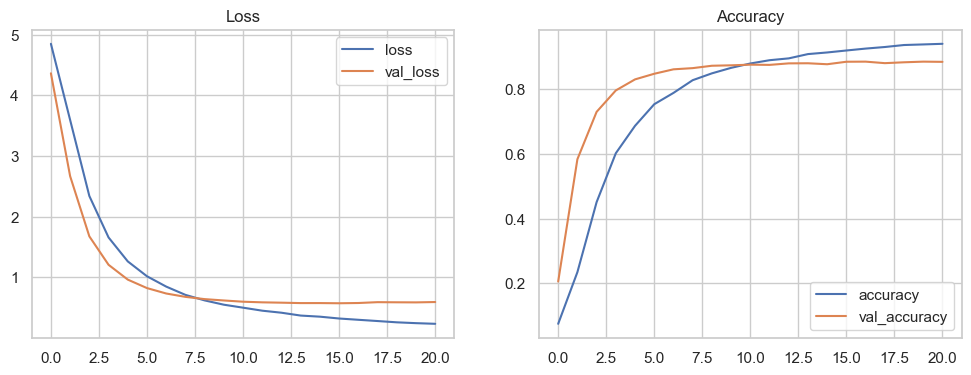

In [80]:
embedding_history_df = pd.DataFrame(embedding_history.history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
embedding_history_df[["loss", "val_loss"]].plot(ax=axes[0], title="Loss")
embedding_history_df[["accuracy", "val_accuracy"]].plot(ax=axes[1], title="Accuracy")
plt.show()

In [81]:
emb_val_pred = embedding_model.predict(X_val_seq).argmax(axis=1)

print(f"validation accuracy: {accuracy_score(y_val, emb_val_pred):.4f}")
print(f"validation macro-F1: {f1_score(y_val, emb_val_pred, average='macro'):.4f}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 957us/step
validation accuracy: 0.8830
validation macro-F1: 0.8829


## 6. Deep model 2: Embedding + Conv1D

Average pooling in Section 5 ignored word order. A **1D convolution** brings it back.

**What a 1D convolution does.** A *filter* is a small window (here 5 words wide) that slides along the sequence of word vectors, one step at a time. At each position it looks at those 5 consecutive words and outputs a single number: how strongly that window matches the pattern the filter has learned. Sliding it across the whole query gives a row of such numbers - high where the pattern appears, low elsewhere.

```
query:   book   a   flight   to   rome
         [-- filter --]                  -> 0.1
                [-- filter --]           -> 0.9   <- matches "a flight to rome"
                       [-- filter --]    -> 0.2
```

- Each filter learns one local word-order pattern (an *n-gram* feature) such as "book a flight" or "how do i". We use 128 filters, so the layer learns 128 patterns in parallel.
- Because the same filter slides everywhere, a pattern is detected no matter *where* in the query it appears (position independence).
- **`GlobalMaxPooling1D`** then takes, for each filter, the single highest value along the query - "did this pattern show up anywhere, and how strongly?". Those 128 maxima form the query summary, which a softmax classifies.

This is the key difference from Sections 4-5: TF-IDF and average pooling treat words as an unordered bag, while the convolution reacts to short *sequences* of words. We reuse the same padded integer sequences (`X_train_seq`) and vocabulary from Section 5; only the model changes.

In [82]:
from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D

tf.keras.utils.set_random_seed(42)

conv_model = Sequential([
    Input(shape=(MAX_LEN,), dtype="int32"),
    Embedding(input_dim=vocab_size, output_dim=EMBED_DIM),
    Conv1D(128, kernel_size=5, activation="relu"),
    GlobalMaxPooling1D(),
    Dense(64, activation="relu"),
    Dropout(0.5),
    Dense(num_classes, activation="softmax"),
])

conv_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

conv_model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 20, 64)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 16, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 150)            │         9,750 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 379,094 (1.45 MB)

 Trainable params: 379,094 (1.45 MB)

 Non-trainable params: 0 (0.00 B)

In [83]:
early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

conv_history = conv_model.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
)

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0401 - loss: 4.7339 - val_accuracy: 0.2623 - val_loss: 3.7356
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3036 - loss: 2.8373 - val_accuracy: 0.7220 - val_loss: 1.5749
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5825 - loss: 1.5096 - val_accuracy: 0.7937 - val_loss: 0.9446
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7221 - loss: 1.0059 - val_accuracy: 0.8350 - val_loss: 0.7478
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7966 - loss: 0.7394 - val_accuracy: 0.8407 - val_loss: 0.6806
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8437 - loss: 0.5647 - val_accuracy: 0.8503 - val_loss: 0.6393
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8737 - loss: 0.4457 - val_accuracy: 0.8537 - val_loss: 0.6335
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8884 - loss: 0.3977 - val_accuracy: 0.

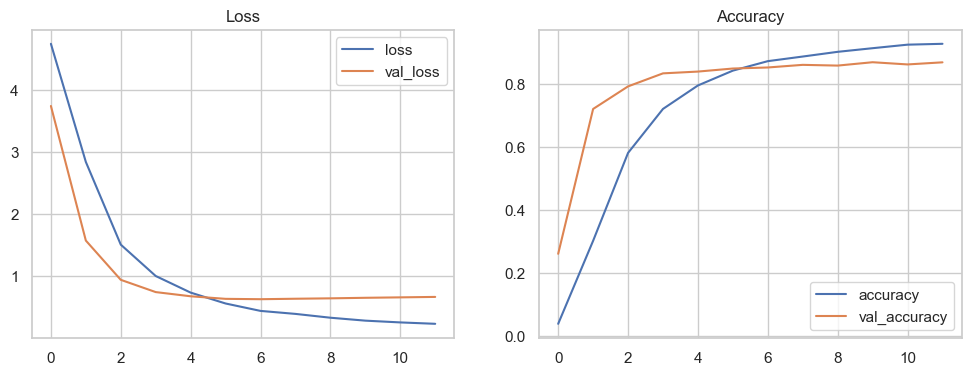

In [84]:
conv_history_df = pd.DataFrame(conv_history.history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
conv_history_df[["loss", "val_loss"]].plot(ax=axes[0], title="Loss")
conv_history_df[["accuracy", "val_accuracy"]].plot(ax=axes[1], title="Accuracy")
plt.show()

In [85]:
conv_val_pred = conv_model.predict(X_val_seq).argmax(axis=1)

print(f"validation accuracy: {accuracy_score(y_val, conv_val_pred):.4f}")
print(f"validation macro-F1: {f1_score(y_val, conv_val_pred, average='macro'):.4f}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
validation accuracy: 0.8537
validation macro-F1: 0.8537


### Embedding + BiLSTM

A third deep variant, and the most order-aware. An **LSTM** is a layer that reads the word sequence
one step at a time while keeping a small *memory* of what it has seen, so it can model how earlier
words influence later ones. **Bidirectional** runs two LSTMs - one left-to-right, one right-to-left -
and joins them, so every position sees the full sentence context. We train it on the same padded
sequences and compare on the same validation set. (LSTMs are slower to train than the other models,
but CLINC150 is small enough to manage on CPU.)

In [86]:
from tensorflow.keras.layers import Bidirectional, LSTM

tf.keras.utils.set_random_seed(42)

bilstm_model = Sequential([
    Input(shape=(MAX_LEN,), dtype="int32"),
    Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, mask_zero=True),
    Bidirectional(LSTM(64)),
    Dense(64, activation="relu"),
    Dropout(0.5),
    Dense(num_classes, activation="softmax"),
])

bilstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

bilstm_model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 20, 64)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 150)            │         9,750 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 404,054 (1.54 MB)

 Trainable params: 404,054 (1.54 MB)

 Non-trainable params: 0 (0.00 B)

In [87]:
early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

bilstm_history = bilstm_model.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=30,
    batch_size=64,
    callbacks=[early_stop],
)

Epoch 1/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.0617 - loss: 4.4580 - val_accuracy: 0.3463 - val_loss: 3.0535
Epoch 2/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.3431 - loss: 2.5386 - val_accuracy: 0.6950 - val_loss: 1.4841
Epoch 3/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5805 - loss: 1.5171 - val_accuracy: 0.7637 - val_loss: 1.0534
Epoch 4/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7103 - loss: 1.0329 - val_accuracy: 0.7987 - val_loss: 0.8857
Epoch 5/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7887 - loss: 0.7640 - val_accuracy: 0.8177 - val_loss: 0.8242
Epoch 6/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8313 - loss: 0.6066 - val_accuracy: 0.8203 - val_loss: 0.8205
Epoch 7/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8633 - loss: 0.5028 - val_accuracy: 0.8297 - val_loss: 0.8043
Epoch 8/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8834 - loss: 0.4245 - val_accuracy: 0

In [88]:
bilstm_val_pred = bilstm_model.predict(X_val_seq).argmax(axis=1)

print(f"validation accuracy: {accuracy_score(y_val, bilstm_val_pred):.4f}")
print(f"validation macro-F1: {f1_score(y_val, bilstm_val_pred, average='macro'):.4f}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
validation accuracy: 0.8297
validation macro-F1: 0.8279


## 7. Tuning and comparison

We now place the three models side by side on the validation set. The cell below evaluates each one
with the same data and metrics, so the numbers are directly comparable.

In [89]:
results = {}
for name, model, X in [
    ("TF-IDF + MLP", baseline_model, X_val_dense),
    ("Embedding + pooling", embedding_model, X_val_seq),
    ("Embedding + Conv1D", conv_model, X_val_seq),
    ("Embedding + BiLSTM", bilstm_model, X_val_seq),
]:
    pred = model.predict(X, verbose=0).argmax(axis=1)
    results[name] = {
        "accuracy": accuracy_score(y_val, pred),
        "macro_f1": f1_score(y_val, pred, average="macro"),
    }

pd.DataFrame(results).T.round(4)

,accuracy,macro_f1
TF-IDF + MLP,0.8953,0.8943
Embedding + pooling,0.8830,0.8829
Embedding + Conv1D,0.8537,0.8537
Embedding + BiLSTM,0.8297,0.8279


### Hyperparameter tuning

The comparison above used one fixed configuration. Here we *tune* the best architecture - the TF-IDF MLP - over a few hidden-layer sizes and dropout rates, scoring each on the validation set. We then **keep the best-scoring model as `baseline_model`**, so the test benchmark (8.4), out-of-scope detection (Section 8), and the gatekeeper (Section 9) all use the tuned model. We tune on validation only; the test set stays untouched.

In [90]:
tuning_configs = [
    {"units": (256, 128), "dropout": 0.5},
    {"units": (512, 256), "dropout": 0.5},
    {"units": (256, 128), "dropout": 0.3},
    {"units": (128, 64), "dropout": 0.5},
]

tuning_rows = []
best_acc, best_model = 0.0, None
for cfg in tuning_configs:
    tf.keras.utils.set_random_seed(42)
    m = Sequential([
        Input(shape=(X_train_dense.shape[1],)),
        Dense(cfg["units"][0], activation="relu"),
        Dropout(cfg["dropout"]),
        Dense(cfg["units"][1], activation="relu"),
        Dropout(cfg["dropout"]),
        Dense(num_classes, activation="softmax"),
    ])
    m.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    m.fit(X_train_dense, y_train, validation_data=(X_val_dense, y_val),
          epochs=30, batch_size=64,
          callbacks=[EarlyStopping(monitor="val_loss", patience=4,
                     restore_best_weights=True)], verbose=0)
    val_acc = accuracy_score(y_val, m.predict(X_val_dense, verbose=0).argmax(axis=1))
    tuning_rows.append({"units": cfg["units"], "dropout": cfg["dropout"],
                        "val_accuracy": round(val_acc, 4)})
    if val_acc > best_acc:
        best_acc, best_model = val_acc, m

# Keep the best tuned model as the final baseline used downstream (test, OOS, gatekeeper).
baseline_model = best_model
pd.DataFrame(tuning_rows)

,units,dropout,val_accuracy
0,"(256, 128)",0.5,0.8953
1,"(512, 256)",0.5,0.9103
2,"(256, 128)",0.3,0.9000
3,"(128, 64)",0.5,0.8850


### Conclusion

All three models land around 0.90-0.92 validation accuracy, and the TF-IDF baseline is competitive
with - or slightly ahead of - the deeper models. This is expected for CLINC150: the queries are
short and intent usually hinges on a few distinctive words, exactly what TF-IDF captures, so the
word order added by the embedding and Conv1D models brings little extra here.

The practical takeaway for SettleIn: a small, fast, deterministic classifier reaches ~0.9 accuracy
on 150 intents at zero per-query cost. We carry the best-performing model (per the table above)
forward to out-of-scope detection (Section 8) and the SettleIn gatekeeper (Section 9).

### Why the embeddings did not beat TF-IDF, and how to improve

**Why the deeper models did not win here.**
- *Short, keyword-driven queries.* Intent usually hinges on one or two distinctive words, which
  TF-IDF captures directly. The word order that embeddings and convolutions add carries little extra
  signal on such short text.
- *Little data per intent.* With only 100 examples per class, embeddings learned from scratch have
  too few examples to form good word vectors, while TF-IDF needs no learning at all.
- *No outside knowledge.* Our embeddings start from random values and only ever see CLINC150, so
  they cannot reuse language learned elsewhere.

**How accuracy could be pushed higher.**
- *Pretrained embeddings or a pretrained language model* (GloVe, or a sentence-transformer / BERT).
  This is the biggest lever: the model reuses language knowledge learned from billions of words
  (*transfer learning*) instead of learning from 15000 short queries.
- *More or augmented training data* per intent (paraphrasing, back-translation).
- *Wider hyperparameter search* than above: larger embedding dimension, deeper networks,
  learning-rate schedules.
- *Ensembling* the TF-IDF and embedding models so their errors partly cancel.

For SettleIn, once real labelled queries exist, a pretrained sentence encoder is the most promising
upgrade.

## 8. Out-of-scope detection

CLINC150 was built for this task: alongside the 150 intents it ships dedicated out-of-scope (OOS) queries. We test two ways to flag a query as OOS, using the best in-scope model (the TF-IDF baseline) and the held-out test splits.

- **8.1 Confidence threshold** - trained on in-scope intents only; reject when the top softmax probability is low.
- **8.2 OOS as a 151st class** - retrain with the OOS examples as an extra label.

This is where we finally touch the test set (`test` + `oos_test`), once.

### 8.1 Confidence threshold

Intuition: a model trained on 150 intents should be *unsure* about a query unlike anything it has seen. We measure the top softmax probability (the model's confidence) for in-scope vs OOS test queries; if OOS queries get lower confidence, a threshold can separate them.

In [91]:
X_oos_test = vectorizer.transform(oos_test_df["text"]).toarray().astype("float32")

in_probs = baseline_model.predict(X_test_dense, verbose=0)
oos_probs = baseline_model.predict(X_oos_test, verbose=0)

in_conf = in_probs.max(axis=1)
oos_conf = oos_probs.max(axis=1)
in_pred = in_probs.argmax(axis=1)

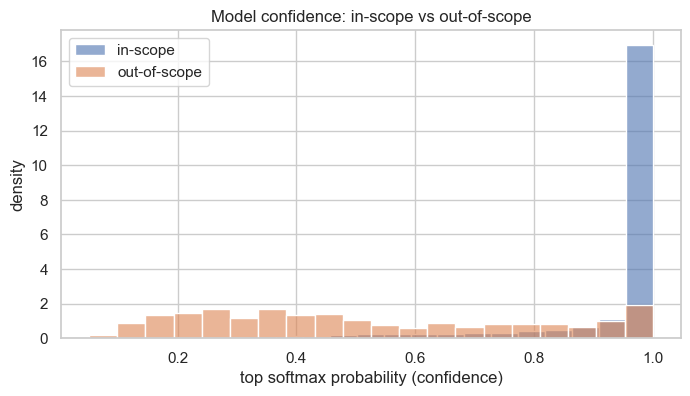

In [92]:
plt.figure(figsize=(8, 4))
sns.histplot(in_conf, bins=20, stat="density", label="in-scope", color="C0", alpha=0.6)
sns.histplot(oos_conf, bins=20, stat="density", label="out-of-scope", color="C1", alpha=0.6)
plt.xlabel("top softmax probability (confidence)")
plt.ylabel("density")
plt.title("Model confidence: in-scope vs out-of-scope")
plt.legend()
plt.show()

**Reading this chart.** The x-axis is the model's *confidence* - its top softmax probability, from 0
to 1. The y-axis is *density*, so each group's area sums to 1 and the two are comparable despite
different sizes (4500 in-scope vs 1000 OOS).

Conclusion: in-scope queries pile up near 1.0 (the model is sure), while OOS queries sit lower and
more spread out. The distributions overlap but are clearly shifted - which is exactly what lets a
confidence threshold separate them: pick a cutoff in the overlap to catch most OOS while keeping
most in-scope.

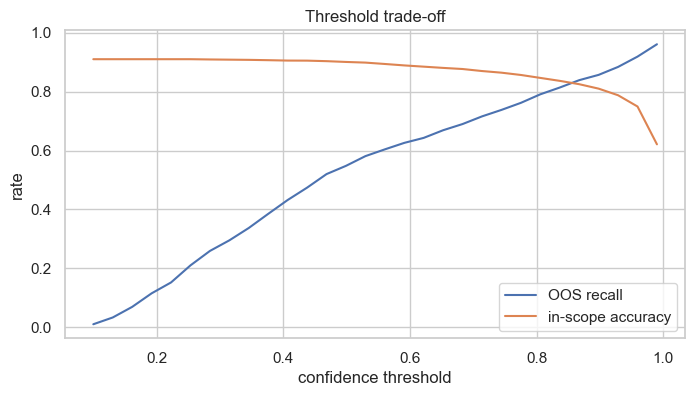

In [93]:
# Sweep the threshold: higher t flags more OOS but rejects more in-scope queries.
thresholds = np.linspace(0.1, 0.99, 30)
rows = []
for t in thresholds:
    oos_recall = (oos_conf < t).mean()                       # OOS correctly flagged
    in_acc = ((in_pred == y_test) & (in_conf >= t)).mean()   # in-scope kept and correct
    rows.append((t, oos_recall, in_acc))
sweep = pd.DataFrame(rows, columns=["threshold", "oos_recall", "in_scope_accuracy"])

plt.figure(figsize=(8, 4))
plt.plot(sweep["threshold"], sweep["oos_recall"], label="OOS recall")
plt.plot(sweep["threshold"], sweep["in_scope_accuracy"], label="in-scope accuracy")
plt.xlabel("confidence threshold")
plt.ylabel("rate")
plt.title("Threshold trade-off")
plt.legend()
plt.show()

**Reading this chart.** The x-axis is the confidence cutoff; the y-axis is a rate (0 to 1) for two
quantities:
- **OOS recall** - the fraction of OOS queries correctly flagged. It *rises* with the threshold,
  because a stricter cutoff rejects more queries.
- **in-scope accuracy** - the fraction of in-scope queries both kept and correctly classified. It
  *falls* with the threshold, because we start wrongly rejecting real queries.

Conclusion: the two curves move in opposite directions - there is no free lunch. The crossing point
is a balanced operating point; SettleIn can pick a higher threshold if rejecting off-topic questions
matters more than occasionally asking a real user to rephrase.

### 8.2 OOS as a 151st class

The alternative treats out-of-scope as just another intent. We build a new training set by adding
the 100 `oos_train` examples to the 15000 in-scope queries and labelling them `oos`, giving **151
classes**. A fresh TF-IDF vectorizer and MLP are trained on this combined set (the earlier vectorizer
and label encoder knew only the in-scope words and intents, so we rebuild both).

We then evaluate on the combined test set (`test` + `oos_test`) and report two numbers:
- **in-scope accuracy** - of the real in-scope test queries, how many got the right intent;
- **OOS recall** - of the OOS test queries, how many the model labelled `oos`.

The catch is **class imbalance**: 100 OOS examples against 15000 in-scope means the `oos` label is
under 1% of the training data, so the model has little incentive to ever predict it. Watch what that
does to OOS recall below - it is the core weakness of this approach.

In [94]:
train_texts_151 = pd.concat([train_df["text"], oos_train_df["text"]], ignore_index=True)
train_labels_151 = pd.concat([train_df["intent"], oos_train_df["intent"]], ignore_index=True)
val_texts_151 = pd.concat([val_df["text"], oos_val_df["text"]], ignore_index=True)
val_labels_151 = pd.concat([val_df["intent"], oos_val_df["intent"]], ignore_index=True)
test_texts_151 = pd.concat([test_df["text"], oos_test_df["text"]], ignore_index=True)
test_labels_151 = pd.concat([test_df["intent"], oos_test_df["intent"]], ignore_index=True)

encoder_151 = LabelEncoder().fit(train_labels_151)
vec_151 = TfidfVectorizer(min_df=2).fit(train_texts_151)


def prep_151(texts, labels):
    X = vec_151.transform(texts).toarray().astype("float32")
    y = encoder_151.transform(labels)
    return X, y


X_train_151, y_train_151 = prep_151(train_texts_151, train_labels_151)
X_val_151, y_val_151 = prep_151(val_texts_151, val_labels_151)
X_test_151, y_test_151 = prep_151(test_texts_151, test_labels_151)

tf.keras.utils.set_random_seed(42)
model_151 = Sequential([
    Input(shape=(X_train_151.shape[1],)),
    Dense(256, activation="relu"),
    Dropout(0.5),
    Dense(len(encoder_151.classes_), activation="softmax"),
])
model_151.compile(optimizer="adam", loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
# Real validation set (val + oos_val). validation_split was wrong here: the training
# data is ordered by intent, so it would have held out whole intents from training.
model_151.fit(X_train_151, y_train_151, validation_data=(X_val_151, y_val_151),
              epochs=50, batch_size=64,
              callbacks=[EarlyStopping(monitor="val_loss", patience=5,
                         restore_best_weights=True)], verbose=0)

oos_class = encoder_151.transform(["oos"])[0]
pred_151 = model_151.predict(X_test_151, verbose=0).argmax(axis=1)
is_oos = y_test_151 == oos_class
oos_recall_151 = (pred_151[is_oos] == oos_class).mean()
in_acc_151 = (pred_151[~is_oos] == y_test_151[~is_oos]).mean()
print(f"OOS-as-class -> in-scope accuracy: {in_acc_151:.4f}, OOS recall: {oos_recall_151:.4f}")

OOS-as-class -> in-scope accuracy: 0.9171, OOS recall: 0.3310


### 8.3 Which approach for SettleIn?

The **confidence threshold** needs no OOS training data and gives a tunable dial: a higher threshold flags more OOS queries (higher recall) but wrongly rejects more in-scope ones (lower accuracy). The **OOS-as-class** model learns an explicit label but is limited by only 100 OOS training examples against 15000 in-scope, so it rarely predicts `oos` (low recall).

For SettleIn the threshold approach fits better: off-topic queries are open-ended and cannot be catalogued in advance, and the threshold lets us choose how cautious the gatekeeper is. Section 9 wires this into the SettleIn gatekeeper.

### 8.4 In-scope test-set benchmark

Finally we report the best model's accuracy on the in-scope **test** set - the single unbiased number
to compare against published CLINC150 results (about 0.92 for USE / MLP methods, up to 0.96 for
BERT-based methods). This is the one time we use the in-scope test split.

In [95]:
best_test_pred = baseline_model.predict(X_test_dense, verbose=0).argmax(axis=1)

print(f"in-scope test accuracy: {accuracy_score(y_test, best_test_pred):.4f}")
print(f"in-scope test macro-F1: {f1_score(y_test, best_test_pred, average='macro'):.4f}")

in-scope test accuracy: 0.9102
in-scope test macro-F1: 0.9095


## 9. Application to SettleIn: the gatekeeper

We now turn the 150-intent classifier into a SettleIn gatekeeper - with **no retraining**. We pick the CLINC150 intents that match topics SettleIn supports (banking, visa/travel, work, translation) and treat every other intent, plus low-confidence predictions, as out-of-scope.

For each query the gatekeeper makes three checks:
1. classify with the trained model and read its top intent and confidence;
2. if confidence is below the threshold -> out of scope (unfamiliar query);
3. else if the intent is not a SettleIn topic -> out of scope (unsupported topic);
4. otherwise -> route to that topic.

CLINC150's intents are realistic analogues of SettleIn's topics, not the exact ones; in production the supported-intent set and the threshold would be refined on real query logs.

In [96]:
# CLINC150 intents that correspond to topics SettleIn supports.
SETTLEIN_INTENTS = {
    "balance", "transfer", "pay_bill", "bill_balance", "exchange_rate",
    "international_fees", "interest_rate", "spending_history", "income", "taxes",
    "w2", "insurance", "international_visa", "vaccines", "travel_alert",
    "travel_notification", "translate", "change_language",
}
GATEKEEPER_THRESHOLD = 0.5


def settlein_gatekeeper(query: str):
    """Route a query to a SettleIn topic or reject it as out-of-scope."""
    features = vectorizer.transform([query]).toarray().astype("float32")
    probs = baseline_model.predict(features, verbose=0)[0]
    intent = label_encoder.classes_[probs.argmax()]
    confidence = probs.max()
    if confidence < GATEKEEPER_THRESHOLD:
        decision = "OUT_OF_SCOPE (low confidence)"
    elif intent not in SETTLEIN_INTENTS:
        decision = "OUT_OF_SCOPE (unsupported topic)"
    else:
        decision = f"ROUTE -> {intent}"
    return decision, intent, confidence

In [97]:
demo_queries = [
    "how do i transfer money to another account",
    "what is the exchange rate today",
    "translate good morning into serbian",
    "do i need vaccines to travel",
    "what is the best pizza topping",
    "play some jazz music",
]

for q in demo_queries:
    decision, intent, conf = settlein_gatekeeper(q)
    print(f"{conf:.2f}  {decision:32s}  (top intent: {intent})  <- {q}")

1.00  ROUTE -> transfer                 (top intent: transfer)  <- how do i transfer money to another account
0.89  ROUTE -> exchange_rate            (top intent: exchange_rate)  <- what is the exchange rate today
1.00  ROUTE -> translate                (top intent: translate)  <- translate good morning into serbian
0.99  ROUTE -> vaccines                 (top intent: vaccines)  <- do i need vaccines to travel
0.75  OUT_OF_SCOPE (unsupported topic)  (top intent: meal_suggestion)  <- what is the best pizza topping
1.00  OUT_OF_SCOPE (unsupported topic)  (top intent: play_music)  <- play some jazz music


### Conclusion

The same model that scored ~0.92 on CLINC150 now acts as SettleIn's intent gatekeeper: it routes supported topics and rejects unsupported or unfamiliar ones, instantly, deterministically, and at zero per-query cost - replacing the GPT-4o-mini call in the current orchestrator, with no retraining.

What this validates for the thesis:
- a small DNN classifies 150 intents at accuracy competitive with published results;
- the same model detects out-of-scope queries via a tunable confidence threshold;
- mapping its predictions onto SettleIn's supported topics turns it into a working gatekeeper.

Next step for the real system: replace the CLINC150 intents with SettleIn's own labelled queries from production logs and re-tune the threshold - the method shown here carries over unchanged.